# METEOR Crop Yield Impact Demo

Demonstrates the integrated GGCMI Phase 2 crop yield emulator.

**What this notebook does:**
1. Trains METEOR for `tas` + `pr` on a CMIP6 model
2. Generates an SSP2-4.5 climate ensemble
3. Passes the `crop_yield` config to compute maize and spring wheat yields across SSP scenarios
4. Plots yield trajectories and a multi-scenario comparison

Coefficient files (~110 MB each) are downloaded from Zenodo record 3592453 on first run and cached locally.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from meteor import MeteorInterface

CACHE_DIR = '../cache'
MODEL     = 'NorESM2-MM'
CROP_MODEL = 'LPJmL'
CROPS     = ['maize', 'spring_wheat']
VARIANT   = 'A0'       # no adaptation
N_FERT    = 100        # kg N / ha / yr

print('✅ Imports complete')

✅ Imports complete


## 2. Create and train emulator

Both `tas` and `pr` are required for the crop yield module.

In [2]:
emulator = MeteorInterface(
    model=MODEL,
    variables=['tas', 'pr'],
    cache_dir=CACHE_DIR,
)
emulator.train(verbose=True)

Training METEOR emulator for NorESM2-MM
Variables: tas, pr

🔧 Training TAS...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model name mismatch: expected 'cmip6-NorESM2-MM-aer', found 'cmip6-NorESM2-MM-aer-tas'
🔧 Preparing pattern scaling training data for NorESM2-MM...
   ✅ Training data prepared for experiments:  ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 351 emission records
   ✅ Config: 1750-2100, emissions start: 1850
📦 Loading cached pattern scaling model from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
   → Training noise model...
Model loaded from ../cache/noise_models/NorESM2-MM_tas_noise_model.pkl
      ✓ Using cached noise model
   ✅ TAS training complete

🔧 Training PR...
   → Training pattern scaling model...
      ⚠️  Cache miss: Mode

## 3. Generate SSP2-4.5 ensemble with crop yields

Crop yield is computed from the **deterministic pattern scaling** (annual forced response) rather than individual monthly realisations, because annual noise averages to approximately zero and the GGCMI emulator takes annual-mean inputs.  Results are therefore a single trajectory per aggregation region.

In [3]:
ensemble_245 = emulator.generate_ensemble_outputs(
    scenario='ssp245',
    start_year=2015,
    end_year=2100,
    n_realizations=10,
    timeseries=['global', 'regional:EAS', 'regional:SAS', 'regional:WAF'],
    impacts={
        'tas': {'degree_days': {'hdd_base': 18.0}},   # existing impact
        'crop_yield': {                                 # NEW
            'crops': CROPS,
            'crop_model': CROP_MODEL,
            'variant': VARIANT,
            'N': N_FERT,
        },
    },
    verbose=True,
)

print('\nCrop impact keys:', list(ensemble_245.crop_impacts.keys()))
for crop in CROPS:
    for key, arr in ensemble_245.crop_impacts[crop].items():
        print(f'  {crop} / {key}: shape={arr.shape}, mean={arr.mean():.2f} t dm/ha/yr')

Generating ensemble for ssp245
  Years: 2015-2100
  Realizations: 10

📊 Generating TAS...
   → Time series: 4 aggregations
      → Computing pattern scaling for tas, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 10 stochastic PC realizations...
      • global
      • regional:EAS
      • regional:SAS
      • regional:WAF
   → Computing impact metrics...
         • HDD for global
         • CDD for global
         • HDD for regional:EAS
         • CDD for regional:EAS
         • HDD for regional:SAS
         • CDD for regional:SAS
         • HDD for regional:WAF
         • CDD for regional:WAF
   ✅ TAS complete

📊 Generating PR...
   → Time series: 4 aggregations
      → Computing pattern scaling for pr, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for pr...
      → Using 2015 baseline for PR inste

## 4. Plot global yield trajectories under SSP2-4.5

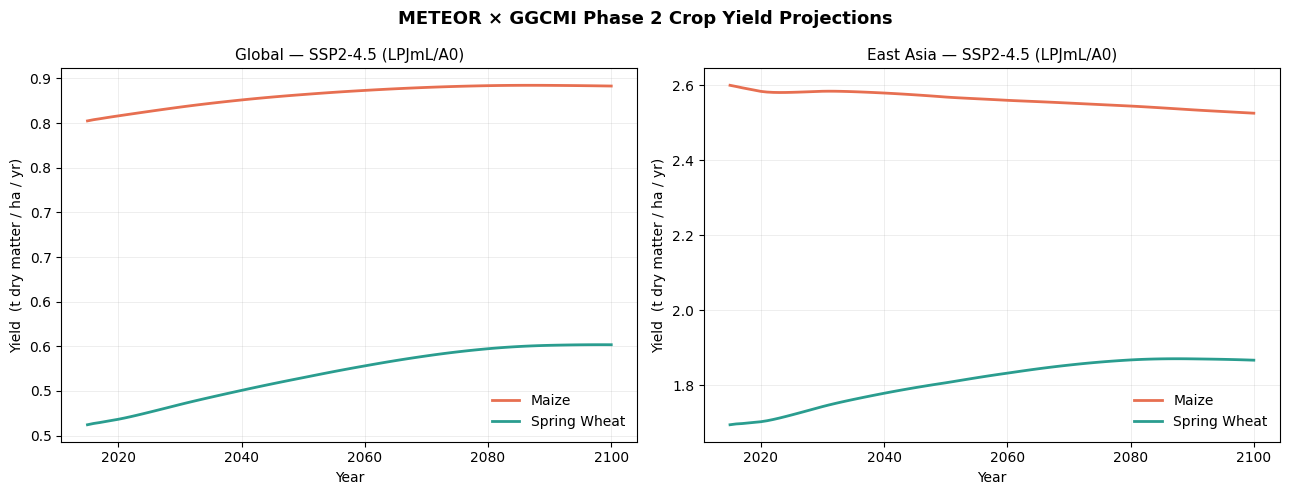

In [4]:
years_245 = np.arange(2015, 2101)

crop_colors = {'maize': '#E76F51', 'spring_wheat': '#2A9D8F'}
crop_labels = {'maize': 'Maize', 'spring_wheat': 'Spring Wheat'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

regions = [('global', 'Global'), ('regional:EAS', 'East Asia')]

for ax, (reg_key, reg_label) in zip(axes, regions):
    for crop in CROPS:
        arr = ensemble_245.crop_impacts[crop][reg_key]
        ax.plot(years_245, arr, color=crop_colors[crop],
                linewidth=2, label=crop_labels[crop])

    ax.set_title(f'{reg_label} — SSP2-4.5 ({CROP_MODEL}/{VARIANT})', fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Yield  (t dry matter / ha / yr)')
    ax.legend(frameon=False)
    ax.grid(alpha=0.3, linewidth=0.5)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.suptitle('METEOR × GGCMI Phase 2 Crop Yield Projections', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Multi-scenario comparison (global maize yield)

Run the same crop config for SSP1-2.6, SSP3-7.0 and SSP5-8.5 and compare trajectories.

In [5]:
scenarios = {
    'ssp126': {'color': '#1a6faf', 'label': 'SSP1-2.6'},
    'ssp245': {'color': '#f4a261', 'label': 'SSP2-4.5'},
    'ssp370': {'color': '#e76f51', 'label': 'SSP3-7.0'},
    'ssp585': {'color': '#9e2a2b', 'label': 'SSP5-8.5'},
}

crop_impacts_all = {}

for ssp in scenarios:
    print(f'Running {ssp}...')
    ens = emulator.generate_ensemble_outputs(
        scenario=ssp,
        start_year=2015,
        end_year=2100,
        n_realizations=1,
        timeseries=['global'],
        impacts={
            'crop_yield': {
                'crops': ['maize'],
                'crop_model': CROP_MODEL,
                'variant': VARIANT,
                'N': N_FERT,
            }
        },
        verbose=False,
    )
    crop_impacts_all[ssp] = ens.crop_impacts['maize']['global']

print('✅ All scenarios complete')

Running ssp126...
Running ssp245...
Running ssp370...
Running ssp585...
✅ All scenarios complete


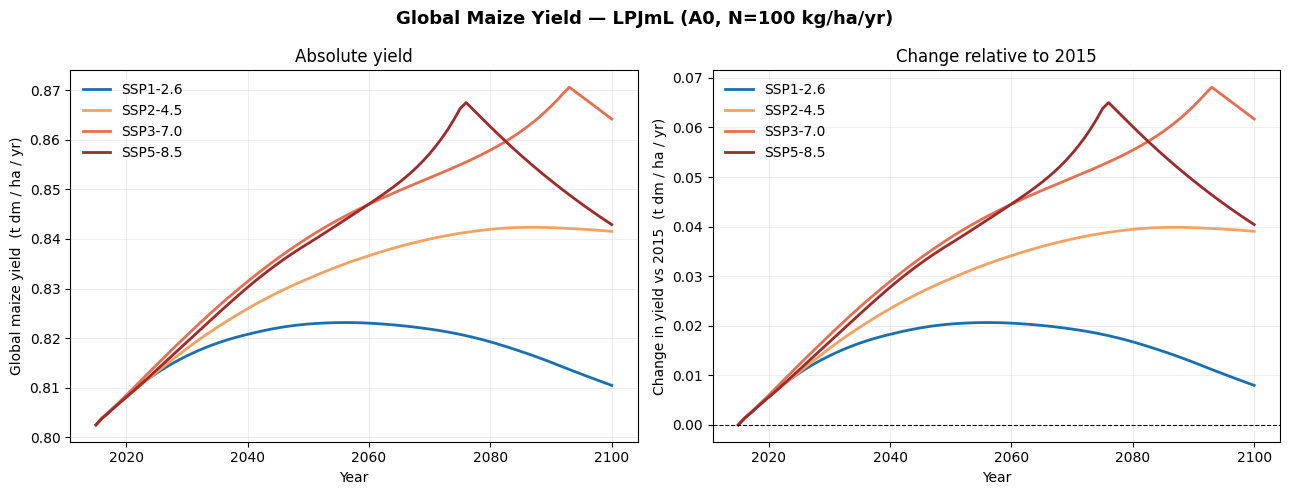


              2030    2060    2100   Δ2015→2100
SSP1-2.6      0.82   0.82   0.81   +0.01
SSP2-4.5      0.82   0.84   0.84   +0.04
SSP3-7.0      0.82   0.85   0.86   +0.06
SSP5-8.5      0.82   0.85   0.84   +0.04


In [6]:
years = np.arange(2015, 2101)
baseline = crop_impacts_all['ssp126'][0]   # use first value as reference

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absolute yield
ax = axes[0]
for ssp, meta in scenarios.items():
    ax.plot(years, crop_impacts_all[ssp], color=meta['color'],
            linewidth=2, label=meta['label'])
ax.set_ylabel('Global maize yield  (t dm / ha / yr)')
ax.set_xlabel('Year')
ax.set_title('Absolute yield')
ax.legend(frameon=False)
ax.grid(alpha=0.3, linewidth=0.5)

# Change relative to 2015
ax = axes[1]
for ssp, meta in scenarios.items():
    delta = crop_impacts_all[ssp] - crop_impacts_all[ssp][0]
    ax.plot(years, delta, color=meta['color'],
            linewidth=2, label=meta['label'])
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_ylabel('Change in yield vs 2015  (t dm / ha / yr)')
ax.set_xlabel('Year')
ax.set_title('Change relative to 2015')
ax.legend(frameon=False)
ax.grid(alpha=0.3, linewidth=0.5)

plt.suptitle(
    f'Global Maize Yield — {CROP_MODEL} ({VARIANT}, N={N_FERT} kg/ha/yr)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

# Summary table
print(f'\n{" ":12}  2030    2060    2100   Δ2015→2100')
for ssp, meta in scenarios.items():
    arr = crop_impacts_all[ssp]
    y2030 = arr[2030-2015]
    y2060 = arr[2060-2015]
    y2100 = arr[-1]
    delta = y2100 - arr[0]
    print(f'{meta["label"]:12}  {y2030:.2f}   {y2060:.2f}   {y2100:.2f}   {delta:+.2f}')

## 6. Regional breakdown (end-of-century)

Compare maize yield changes across regions for SSP2-4.5 and SSP5-8.5.

In [8]:
REGIONS = {
    'global':        'Global',
    'regional:EAS':  'East Asia',
    'regional:SAS':  'South Asia',
    'regional:WAF':  'Western Africa',
    'regional:NEAF': 'NE Africa',
    'regional:ENA':  'E. N. America',
    'regional:WCE':  'W&C Europe',
}

regional_results = {}
for ssp in ['ssp245', 'ssp585']:
    print(f'Running {ssp} regional...')
    ens = emulator.generate_ensemble_outputs(
        scenario=ssp,
        start_year=2015,
        end_year=2100,
        n_realizations=1,
        timeseries=list(REGIONS.keys()),
        impacts={
            'crop_yield': {
                'crops': ['maize'],
                'crop_model': CROP_MODEL,
                'variant': VARIANT,
                'N': N_FERT,
            }
        },
        verbose=False,
    )
    regional_results[ssp] = {
        reg: ens.crop_impacts['maize'][reg] for reg in REGIONS
    }

print('✅ Regional runs complete')


Running ssp245 regional...
Running ssp585 regional...
✅ Regional runs complete


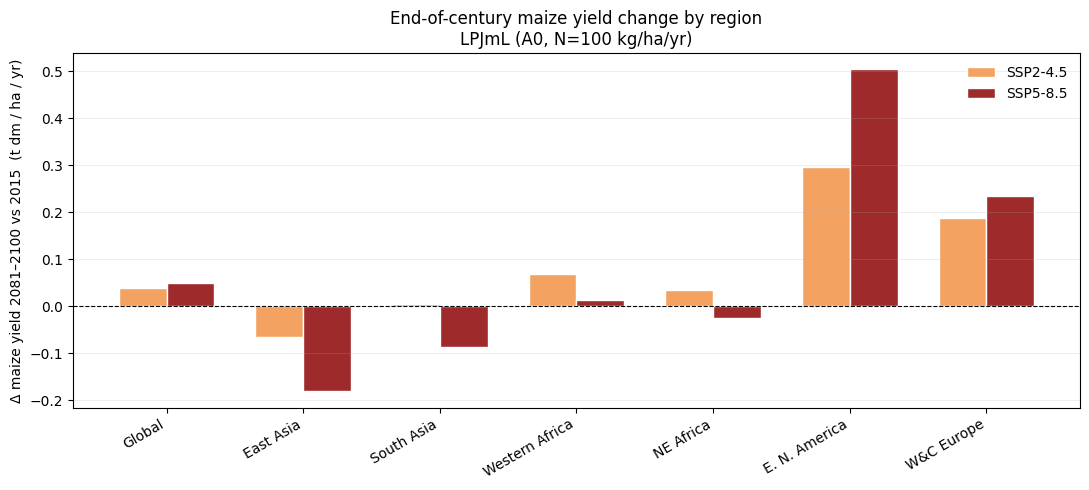

In [9]:
reg_labels = list(REGIONS.values())
reg_keys   = list(REGIONS.keys())

# Δ yield 2015→2081-2100 mean
def end_century_change(ssp, reg_key):
    arr = regional_results[ssp][reg_key]
    return arr[-20:].mean() - arr[0]

delta_245 = [end_century_change('ssp245', k) for k in reg_keys]
delta_585 = [end_century_change('ssp585', k) for k in reg_keys]

x = np.arange(len(reg_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars245 = ax.bar(x - width/2, delta_245, width, label='SSP2-4.5',
                 color='#f4a261', edgecolor='white')
bars585 = ax.bar(x + width/2, delta_585, width, label='SSP5-8.5',
                 color='#9e2a2b', edgecolor='white')

ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(reg_labels, rotation=30, ha='right')
ax.set_ylabel('Δ maize yield 2081–2100 vs 2015  (t dm / ha / yr)')
ax.set_title(
    f'End-of-century maize yield change by region\n'
    f'{CROP_MODEL} ({VARIANT}, N={N_FERT} kg/ha/yr)',
    fontsize=12
)
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()